In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

# Cleaning


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetes_prediction_dataset.csv')
df = df.drop_duplicates()
df['age'] = df['age'].astype(int)
df['smoking_history'] = df['smoking_history'].replace('No Info', 'unknown')
df = df[(df['bmi'] >= 10) & (df['bmi'] <= 60)]
df['gender'] = df['gender'].str.lower()
df['bmi'] = df['bmi'].round(2)
df['HbA1c_level'] = df['HbA1c_level'].round(2)
df = df.rename(columns={
    'HbA1c_level': 'hba1c_level',
    'blood_glucose_level': 'blood_glucose',
    'heart_disease': 'heart_disease_history'
})

print(df.shape)
df.head()


(96031, 9)


,gender,age,hypertension,heart_disease_history,smoking_history,bmi,hba1c_level,blood_glucose,diabetes
0,female,80,0,1,never,25.19,6.6,140,0
1,female,54,0,0,unknown,27.32,6.6,80,0
2,male,28,0,0,never,27.32,5.7,158,0
3,female,36,0,0,current,23.45,5.0,155,0
4,male,76,1,1,current,20.14,4.8,155,0



# Encoding

In [4]:
df_encoded = pd.get_dummies(df, columns=['gender', 'smoking_history'])
df_encoded.head()
print(df_encoded.columns.tolist())
print(df_encoded.shape)

['age', 'hypertension', 'heart_disease_history', 'bmi', 'hba1c_level', 'blood_glucose', 'diabetes', 'gender_female', 'gender_male', 'gender_other', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'smoking_history_unknown']
(96031, 16)


# Define features and target

In [5]:
X = df_encoded.drop(columns=['diabetes'])
y = df_encoded['diabetes']

# Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to training data only

In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 70068, 1: 6756}
After SMOTE: {0: 70068, 1: 70068}


# Part 1: Scaling

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Part 2: KNN Model

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_sm)
y_pred_knn = knn.predict(X_test_scaled)

# Part 3: Evaluation

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("ROC-AUC Score:", roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1]))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     17518
           1       0.65      0.70      0.67      1689

    accuracy                           0.94     19207
   macro avg       0.81      0.83      0.82     19207
weighted avg       0.94      0.94      0.94     19207

ROC-AUC Score: 0.9155366608960649


# KNN Confusion Matrix

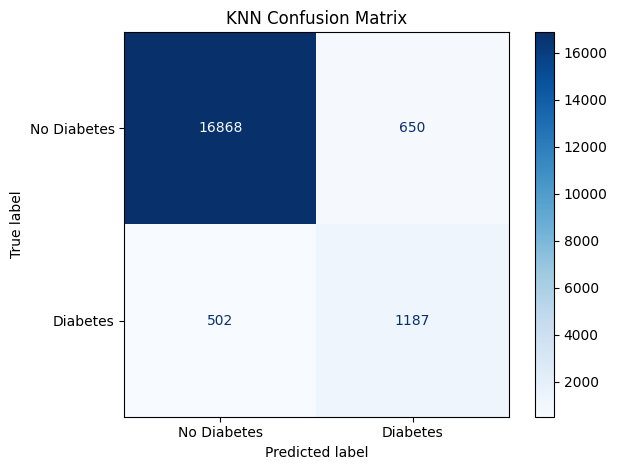

In [11]:
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.tight_layout()
plt.show()

# Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC Score:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     17518
           1       0.64      0.75      0.69      1689

    accuracy                           0.94     19207
   macro avg       0.81      0.85      0.83     19207
weighted avg       0.95      0.94      0.94     19207

ROC-AUC Score: 0.9581030787515789


# Confusion Matrix

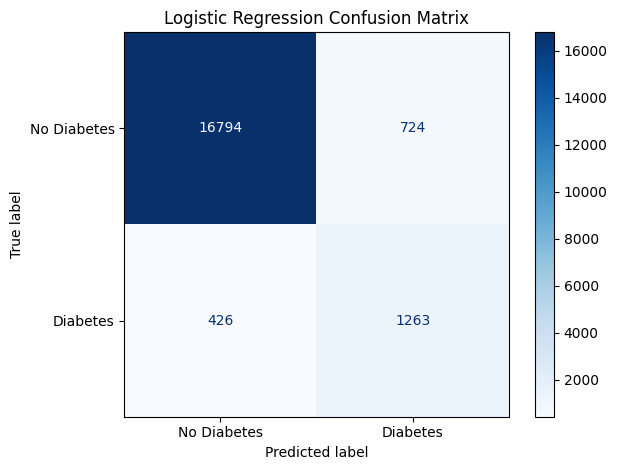

In [13]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Diabetes', 'Diabetes'])
disp_lr.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature importance via coefficients

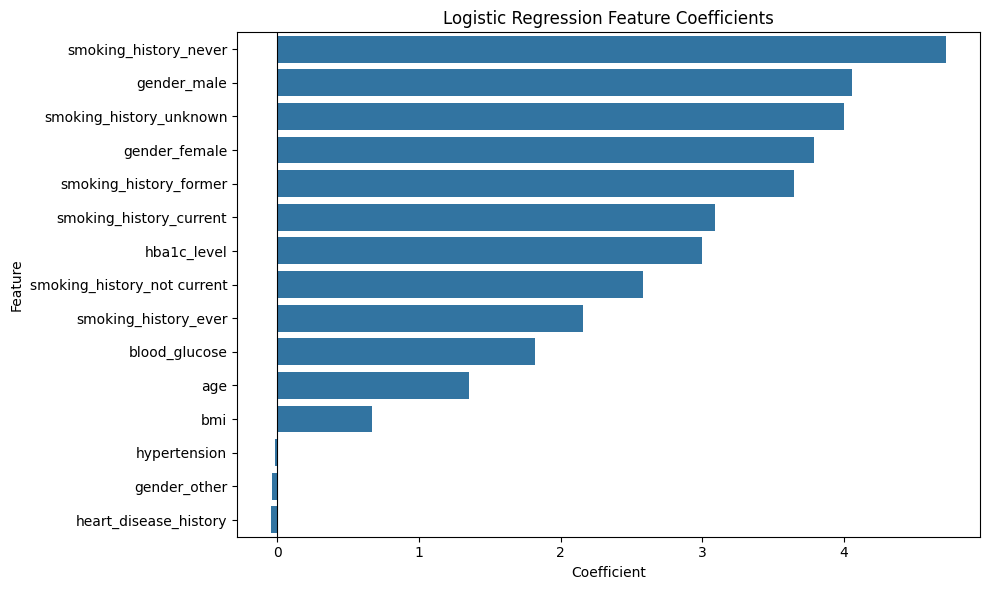

In [14]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Logistic Regression Feature Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17518
           1       0.86      0.71      0.78      1689

    accuracy                           0.96     19207
   macro avg       0.92      0.85      0.88     19207
weighted avg       0.96      0.96      0.96     19207

ROC-AUC Score: 0.9615740751067783


# Confusion Matrix



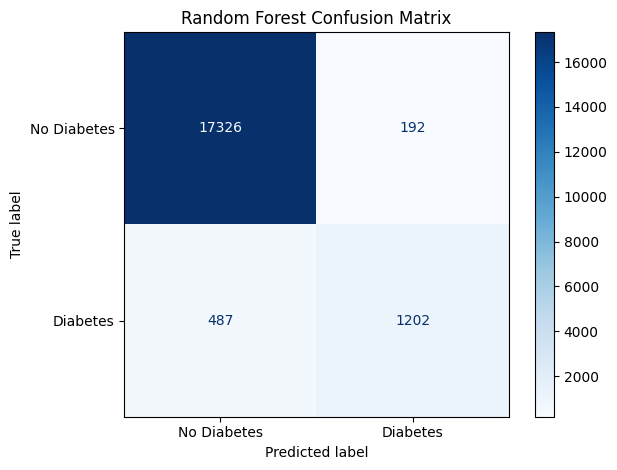

In [16]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Diabetes', 'Diabetes'])
disp_rf.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature importance chart

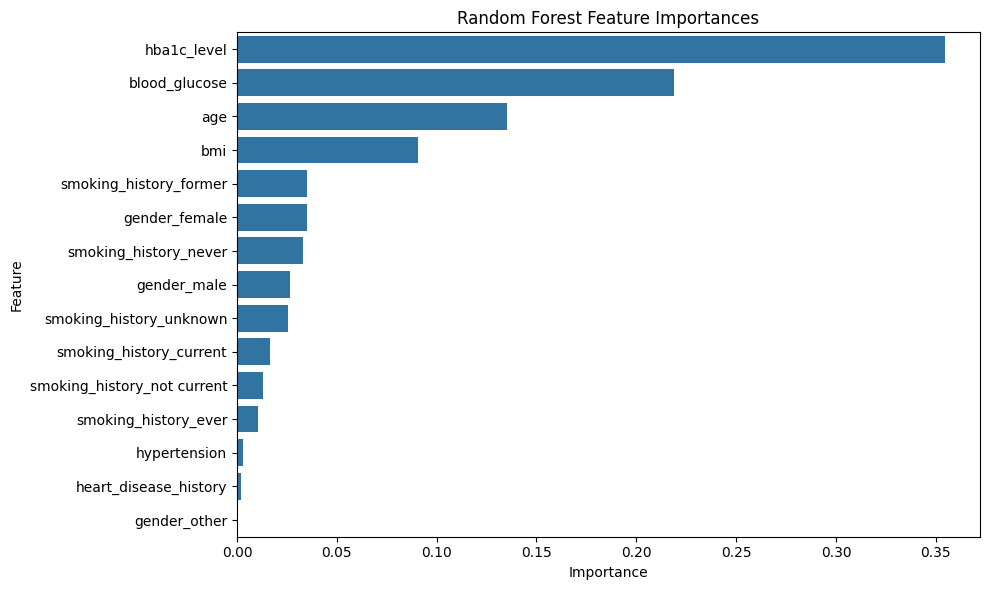

In [18]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

# XGBoost

In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17518
           1       0.95      0.70      0.81      1689

    accuracy                           0.97     19207
   macro avg       0.96      0.85      0.89     19207
weighted avg       0.97      0.97      0.97     19207

ROC-AUC Score: 0.9764715659799061


# Confusion Matrix

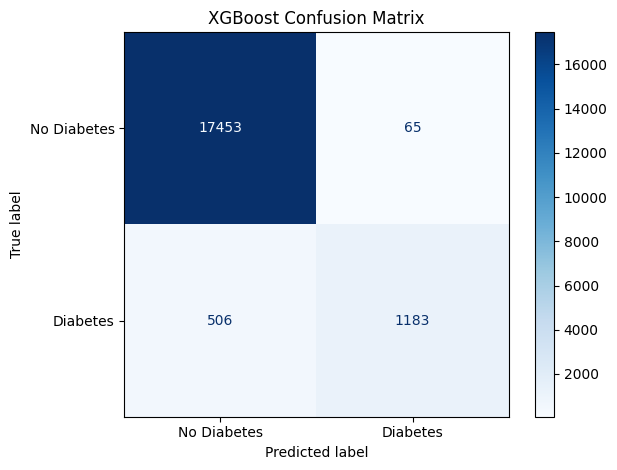

In [20]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Diabetes', 'Diabetes'])
disp_xgb.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC curve comparing all four models on the same chart

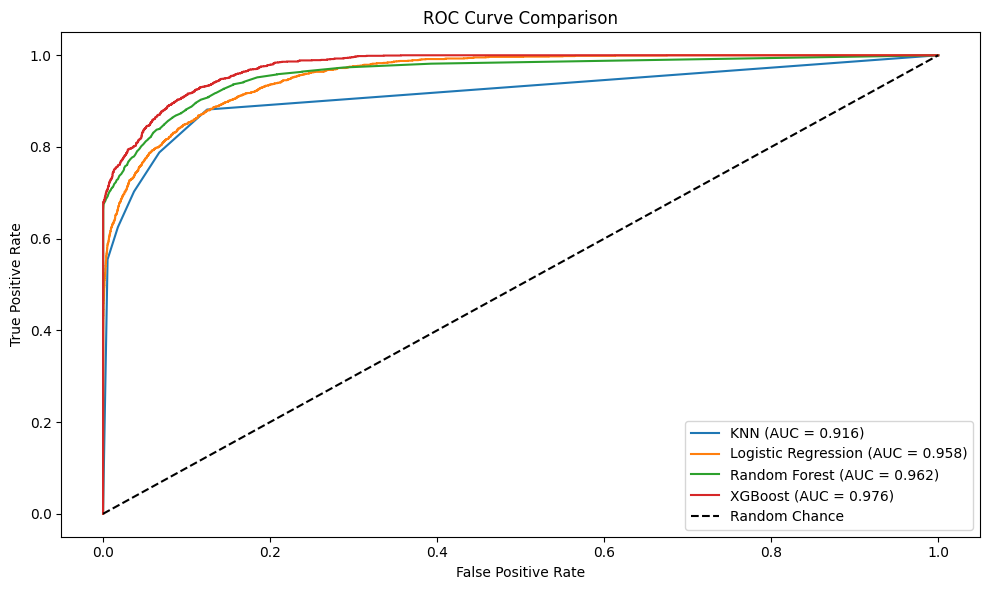

In [21]:
plt.figure(figsize=(10, 6))

models = {
    'KNN': (knn, X_test_scaled),
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest': (rf, X_test),
    'XGBoost': (xgb, X_test)
}

for name, (model, X) in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()